In [5]:
# Load packages
import pandas as pd
import mygene
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Supervised learning models for Q2
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Q3 Calculate roc curve
import os
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Q5 Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

---

## 1. Load expression data

In [6]:
#NOTE Reuse code from previous assignments
# Load gene expression and metadata into dataframes
expr = pd.read_csv("../data/SRP075806/SRP075806.tsv", sep='\t')
meta = pd.read_csv("../data/SRP075806/metadata_SRP075806.tsv", sep='\t')

# Query mygene for gene names
expr = expr.set_index("Gene")
mg = mygene.MyGeneInfo()
print('Querying...')
res = mg.querymany(expr.index.tolist(), scopes="ensembl.gene", fields="symbol", species="human")

# Mapping dataframe
mapping = (pd.DataFrame(res).loc[:, ["query", "symbol"]].dropna()
             .rename(columns={"query": "Ensembl", "symbol": "GeneName"}))

# Use mapping dataframe to build expression matrix
expr = expr.merge(mapping, left_index=True, right_on="Ensembl")
expr = expr.drop(columns="Ensembl").set_index("GeneName")

# If multiple Ensembl IDs map to the same symbol, combine the rows
expr = expr.groupby(expr.index).mean()

print("Expr.shape (with gene names):", expr.shape, '\n')

expr_log = np.log2(expr+1)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Querying...


27 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000188660', 2), ('ENSG00000226506', 2), ('ENSG00000226519', 2), ('E
1224 input query terms found no hit:	['ENSG00000112096', 'ENSG00000116883', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000131484', 'ENS


Expr.shape (with gene names): (32059, 116) 



---

## 2. Supervised Analysis

### 2.a - 5,000 most variable genes

In [7]:
#NOTE reuse code from previous assignments
# Step 1: Compute variance and select top genes
gene_variances = expr_log.var(axis=1)
gene_variances_sorted = gene_variances.sort_values(ascending=False)

subset_sizes = [10, 100, 1000, 5000, 10000]
gene_subsets = {}

for n in subset_sizes:
    top_genes = gene_variances_sorted.head(n).index
    subset = expr_log.loc[top_genes]
    subset_T = subset.T
    scaler = StandardScaler()
    subset_scaled = scaler.fit_transform(subset_T)
    gene_subsets[n] = pd.DataFrame(subset_scaled, index=subset_T.index, columns=subset_T.columns)
    print(f"Top {n} most variable genes subset:", subset_scaled.shape)

Top 10 most variable genes subset: (116, 10)
Top 100 most variable genes subset: (116, 100)
Top 1000 most variable genes subset: (116, 1000)
Top 5000 most variable genes subset: (116, 5000)
Top 10000 most variable genes subset: (116, 10000)


In [8]:
# Split data into train and test sets
target_col = "refinebio_disease"
meta = meta.set_index("refinebio_accession_code")

# use 5000 most variable genes
X = gene_subsets[5000]

# Ensure alignment between expression samples and metadata samples
common_samples = X.index.intersection(meta.index)
X = X.loc[common_samples]
y = meta.loc[common_samples, target_col]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Classes:", le.classes_)

X_train shape: (92, 5000)
X_test shape: (24, 5000)
Classes: ['ngt' 't2d']


### 2.b.i - Support Vector Machine (SVM)

In [9]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

SVM Accuracy: 0.9583333333333334 

              precision    recall  f1-score   support

         ngt       0.92      1.00      0.96        12
         t2d       1.00      0.92      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



### 2.b.ii - Logistic Regression

In [10]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Logistic Regression Accuracy: 0.9583333333333334 

              precision    recall  f1-score   support

         ngt       0.92      1.00      0.96        12
         t2d       1.00      0.92      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



### 2.b.iii - Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Random Forest Accuracy: 1.0 

              precision    recall  f1-score   support

         ngt       1.00      1.00      1.00        12
         t2d       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



### 2.b.iv - K-Nearest Neighbors

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

KNN Accuracy: 0.9583333333333334 

              precision    recall  f1-score   support

         ngt       0.92      1.00      0.96        12
         t2d       1.00      0.92      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



### 2.b.v - Naive Bayes

In [13]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Naïve Bayes Accuracy: 0.7083333333333334 

              precision    recall  f1-score   support

         ngt       0.63      1.00      0.77        12
         t2d       1.00      0.42      0.59        12

    accuracy                           0.71        24
   macro avg       0.82      0.71      0.68        24
weighted avg       0.82      0.71      0.68        24



---

## 3. Find Area Under Reciever Operating Characteristic (AUROC)

In [14]:
# Load clustering results (from assn3)
cluster_csv = "../results/clusters/kmeans_k5.csv"
clusters_df = pd.read_csv(cluster_csv)

clusters_df = clusters_df.set_index("sample_id")
print("Loaded clusters:", cluster_csv)
print(clusters_df.head())

# --- 2) Build sample x model matrices for class predictions (Assignment 1) ---
# models trained previously on disease (assignment1). 
models = {
    "SVM": svm,
    "LogisticRegression": log_reg,
    "RandomForest": rf,
    "KNN": knn,
    "NaiveBayes": nb
}

# predicted class labels (text) and predicted probabilities (for consensus scoring)
pred_labels = pd.DataFrame(index=X_test.index)
pred_probs = pd.DataFrame(index=X_test.index)

for name, model in models.items():
    # labels (as class strings)
    pred_i = model.predict(X_test)
    pred_labels[name] = le.inverse_transform(pred_i)
    
    # probabilities or normalized decision scores
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]  # prob for positive class (index 1)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        # normalize to [0,1]
        scores = (scores - scores.min()) / (scores.max() - scores.min())
        probs = scores
    else:
        # fallback: 1 for predicted positive label, 0 otherwise
        probs = (pred_i == 1).astype(float)
    pred_probs[name] = probs

print("\nPredicted class labels (sample x model):")
display(pred_labels.head())

print("\nPredicted probabilities (sample x model):")
display(pred_probs.head())

# --- 3) Per-sample: how many models predict each class label? ---
# For each sample, count how many models predicted each class (eg 'ngt' and 't2d')
class_counts_per_sample = pred_labels.apply(lambda r: r.value_counts(), axis=1).fillna(0).astype(int)
print("\nClass counts per sample (how many models predicted each class):")
display(class_counts_per_sample.head())

# Also compute a per-sample scalar: max number of models that agreed on a class
class_max_agreement = class_counts_per_sample.max(axis=1)  # e.g., 3 models agreed, 4 models agreed, etc.

# --- 4) Retrain same classifier types to predict clusters (Assignment 3) ---
# Align clusters with our expression samples, and create cluster labels for train/test splits
# clusters_df index should match sample ids (X.index)
common_for_clusters = X.index.intersection(clusters_df.index)
print(f"\nSamples common between expression and clusters: {len(common_for_clusters)}")

# Subset cluster labels to X_train/X_test partitions
cluster_labels_all = clusters_df.loc[common_for_clusters, "cluster_label"].astype(str)

# For train/test matching, we use the same X_train / X_test splits already produced earlier:
# Make sure X_train.index and X_test.index are in cluster_labels_all
y_clusters_train = cluster_labels_all.loc[X_train.index]
y_clusters_test  = cluster_labels_all.loc[X_test.index]

# Encode cluster labels for model training
le_clusters = LabelEncoder()
y_clusters_train_enc = le_clusters.fit_transform(y_clusters_train)
y_clusters_test_enc  = le_clusters.transform(y_clusters_test)

print("\nCluster classes (encoded):", list(le_clusters.classes_))

# Train a new set of models for cluster prediction (one model per method)
cluster_models = {}
for name, base_model in models.items():
    # clone model by re-instancing with equivalent constructor parameters
    if name == "SVM":
        m = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    elif name == "LogisticRegression":
        m = LogisticRegression(max_iter=1000, random_state=42, multi_class='auto')
    elif name == "RandomForest":
        m = RandomForestClassifier(n_estimators=200, random_state=42)
    elif name == "KNN":
        m = KNeighborsClassifier(n_neighbors=5)
    elif name == "NaiveBayes":
        m = GaussianNB()
    else:
        raise ValueError(f"Unknown model name {name}")
    
    # Fit on cluster labels
    m.fit(X_train, y_clusters_train_enc)
    cluster_models[name] = m

# Predict clusters on X_test for each model
pred_clusters = pd.DataFrame(index=X_test.index)
pred_cluster_probs = {}  # if you want probabilities per cluster (dict of DataFrames)

for name, m in cluster_models.items():
    preds_enc = m.predict(X_test)
    preds = le_clusters.inverse_transform(preds_enc)
    pred_clusters[name] = preds
    
    # store predict_proba if available (DataFrame with columns = cluster classes)
    if hasattr(m, "predict_proba"):
        probmat = m.predict_proba(X_test)
        probdf = pd.DataFrame(probmat, index=X_test.index, columns=le_clusters.classes_)
        pred_cluster_probs[name] = probdf

print("\nPredicted clusters (sample x model):")
display(pred_clusters.head())

# --- 5) For each sample: how many models predict the same cluster? ---
# Compute counts of predicted cluster labels per sample (modal cluster counts)
cluster_counts_per_sample = pred_clusters.apply(lambda r: r.value_counts(), axis=1).fillna(0).astype(int)
print("\nCluster prediction counts per sample (how many models predicted each cluster):")
display(cluster_counts_per_sample.head())

# For each sample, get the maximum number of models that agreed on the same cluster
cluster_max_agreement = cluster_counts_per_sample.max(axis=1)

# --- 6) Consensus probability and AUC (for disease labels) ---
# For each sample compute consensus score = mean predicted probability for positive (t2d)
# Identify which class is positive in your earlier LabelEncoder; find index for 't2d'
if 't2d' in le.classes_:
    positive_label = 't2d'
else:
    # fallback to the second class (index 1) if you don't have explicit name
    positive_label = le.classes_[1]

# Consensus score across models (mean model prob for positive class)
consensus_score = pred_probs.mean(axis=1)

# Overall AUC across samples using consensus score
y_test_binary = (y_test == le.transform([positive_label])[0]).astype(int)
consensus_auc = roc_auc_score(y_test_binary, consensus_score)
print(f"\nConsensus AUC (mean model probability for '{positive_label}') across test samples: {consensus_auc:.4f}")

# --- 7) Correlation test: does class-label stability correlate with cluster stability? ---
# Use Spearman correlation between:
#   class_max_agreement (how many models agreed on top class for sample)
#   cluster_max_agreement (how many models agreed on top cluster for sample)
# Align indices (X_test.index)
cm_class = class_max_agreement.loc[X_test.index]
cm_cluster = cluster_max_agreement.loc[X_test.index]

corr, pval = spearmanr(cm_class, cm_cluster)
# multiple testing correction: we only have one test here, but show usage if many tests exist
rej, pvals_corrected, _, _ = multipletests([pval], method='fdr_bh')

print("\n=== Stability correlation (Spearman) ===")
print(f"Spearman rho: {corr:.3f}")
print(f"Raw p-value: {pval:.4e}")
print(f"FDR-corrected p-value: {pvals_corrected[0]:.4e}")
print(f"Reject null after FDR? {bool(rej[0])}")

# --- 8) Tabulate and save results for inspection ---
results_df = pd.DataFrame(index=X_test.index)
results_df["true_class"] = le.inverse_transform(y_test)
results_df["consensus_score"] = consensus_score
results_df["consensus_auc_overall"] = consensus_auc  # same for all samples (overall)
results_df["class_max_model_agreement"] = cm_class
results_df["cluster_max_model_agreement"] = cm_cluster
# Also include class counts and cluster modal label for each sample
# Add class counts as columns with prefix 'classcount_'
for col in class_counts_per_sample.columns:
    results_df[f"classcount_{col}"] = class_counts_per_sample.loc[X_test.index, col].values

# Add cluster modal and its count
results_df["cluster_modal"] = cluster_counts_per_sample.loc[X_test.index].idxmax(axis=1)
results_df["cluster_modal_count"] = cluster_counts_per_sample.loc[X_test.index].max(axis=1)

print("\nPer-sample summary (first 8 rows):")
display(results_df.head(8))

# Save summary to CSV
out_file = "../results/model_cluster_stability_summary.csv"
os.makedirs(os.path.dirname(out_file), exist_ok=True)
#results_df.to_csv(out_file)
print(f"\nSaved per-sample summary to: {out_file}")

# Also save the sample x model label matrices for later analysis
#pred_labels.to_csv("../results/sample_by_model_class_predictions.csv")
#pred_clusters.to_csv("../results/sample_by_model_cluster_predictions.csv")
print("Saved sample x model prediction matrices to ../results/")


Loaded clusters: ../results/clusters/kmeans_k5.csv
            cluster_label
sample_id                
SRR3593218              0
SRR3593219              0
SRR3593220              0
SRR3593221              0
SRR3593222              0

Predicted class labels (sample x model):


,SVM,LogisticRegression,RandomForest,KNN,NaiveBayes
SRR3593332,t2d,t2d,t2d,t2d,ngt
SRR3593284,ngt,ngt,ngt,ngt,ngt
SRR3593329,t2d,t2d,t2d,t2d,t2d
SRR3593270,ngt,ngt,ngt,ngt,ngt
SRR3593278,ngt,ngt,ngt,ngt,ngt



Predicted probabilities (sample x model):


,SVM,LogisticRegression,RandomForest,KNN,NaiveBayes
SRR3593332,0.743331,0.981780,0.800,1.0,7.802996e-239
SRR3593284,0.026469,0.000938,0.105,0.0,0.000000e+00
SRR3593329,0.929832,0.999971,0.975,1.0,1.000000e+00
SRR3593270,0.038620,0.000412,0.100,0.2,0.000000e+00
SRR3593278,0.092985,0.001929,0.125,0.2,0.000000e+00



Class counts per sample (how many models predicted each class):


...

,0,1,3,4
SRR3593332,5,0,0,0
SRR3593284,5,0,0,0
SRR3593329,0,5,0,0
SRR3593270,5,0,0,0
SRR3593278,5,0,0,0



Consensus AUC (mean model probability for 't2d') across test samples: 1.0000

=== Stability correlation (Spearman) ===
Spearman rho: nan
Raw p-value: nan
FDR-corrected p-value: nan
Reject null after FDR? False

Per-sample summary (first 8 rows):


/var/folders/c1/fzk9d1qx44ggsrfbs2b09_s00000gn/T/ipykernel_93522/1866681217.py:150: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(cm_class, cm_cluster)


,true_class,consensus_score,consensus_auc_overall,class_max_model_agreement,cluster_max_model_agreement,classcount_ngt,classcount_t2d,cluster_modal,cluster_modal_count
SRR3593332,t2d,0.705022,1.0,4,5,1,4,0,5
SRR3593284,ngt,0.026481,1.0,5,5,5,0,0,5
SRR3593329,t2d,0.980961,1.0,5,5,0,5,1,5
SRR3593270,ngt,0.067806,1.0,5,5,5,0,0,5
SRR3593278,ngt,0.083983,1.0,5,5,5,0,0,5
SRR3593219,t2d,0.666955,1.0,4,5,1,4,0,5
SRR3593269,t2d,0.477559,1.0,3,5,2,3,0,5
SRR3593318,t2d,0.981918,1.0,5,5,0,5,1,5



Saved per-sample summary to: ../results/model_cluster_stability_summary.csv
Saved sample x model prediction matrices to ../results/


---

## 4. Retrain models using different number of genes

### 4.1 SVM

In [15]:
# Ensure gene_subsets (10,100,1000,10000) already exist from previous preprocessing
# Subset to common samples
target_col = "refinebio_disease"
common_samples = gene_subsets[10000].index.intersection(meta.index) # ["refinebio_accession_code"]
meta_sub = meta.loc[common_samples]

In [16]:
def train_model_auc(model_class, X_dict, y, model_params={}):
    """
    Train model on different gene subsets and return AUCs.
    
    X_dict: dict of {n_genes: DataFrame} 
    y: encoded labels
    model_class: sklearn model class (not instance)
    model_params: dict of params to pass to the model
    """
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    auc_results = {}
    
    for n_genes, X in X_dict.items():
        X = X.loc[y.index]  # align samples
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
        )
        model = model_class(**model_params)
        model.fit(X_train, y_train)
        
        # Use predict_proba if available, else decision_function
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]  # probability for class 1
        else:
            y_prob = model.decision_function(X_test)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())  # scale to 0-1
        
        auc = roc_auc_score(y_test, y_prob)
        auc_results[n_genes] = auc
        print(f"{model_class.__name__} with {n_genes} genes → AUC: {auc:.4f}")
    
    return auc_results

In [17]:
svm_auc = train_model_auc(
    SVC,
    {k: gene_subsets[k] for k in [10, 100, 1000, 10000]},
    meta_sub[target_col],
    model_params={"kernel": "rbf", "C":1.0, "gamma":"scale", "probability":True, "random_state":42}
)

SVC with 10 genes → AUC: 0.9097
SVC with 100 genes → AUC: 0.9792
SVC with 1000 genes → AUC: 1.0000
SVC with 10000 genes → AUC: 0.9931


In [18]:
logreg_auc = train_model_auc(
    LogisticRegression,
    {k: gene_subsets[k] for k in [10, 100, 1000, 10000]},
    meta_sub[target_col],
    model_params={"max_iter":1000, "random_state":42}
)

LogisticRegression with 10 genes → AUC: 0.8403
LogisticRegression with 100 genes → AUC: 1.0000
LogisticRegression with 1000 genes → AUC: 1.0000
LogisticRegression with 10000 genes → AUC: 1.0000


In [19]:
rf_auc = train_model_auc(
    RandomForestClassifier,
    {k: gene_subsets[k] for k in [10, 100, 1000, 10000]},
    meta_sub[target_col],
    model_params={"n_estimators":200, "random_state":42}
)

RandomForestClassifier with 10 genes → AUC: 1.0000
RandomForestClassifier with 100 genes → AUC: 1.0000
RandomForestClassifier with 1000 genes → AUC: 1.0000
RandomForestClassifier with 10000 genes → AUC: 1.0000


In [20]:
knn_auc = train_model_auc(
    KNeighborsClassifier,
    {k: gene_subsets[k] for k in [10, 100, 1000, 10000]},
    meta_sub[target_col],
    model_params={"n_neighbors":5}
)

KNeighborsClassifier with 10 genes → AUC: 0.9514
KNeighborsClassifier with 100 genes → AUC: 0.9722
KNeighborsClassifier with 1000 genes → AUC: 0.9896
KNeighborsClassifier with 10000 genes → AUC: 0.9965


In [21]:
nb_auc = train_model_auc(
    GaussianNB,
    {k: gene_subsets[k] for k in [10, 100, 1000, 10000]},
    meta_sub[target_col]
)

GaussianNB with 10 genes → AUC: 0.6944
GaussianNB with 100 genes → AUC: 0.7083
GaussianNB with 1000 genes → AUC: 0.9653
GaussianNB with 10000 genes → AUC: 0.8333


In [22]:
# Combination Table for viewing / presentation
auc_table = pd.DataFrame({
    "SVM": svm_auc,
    "Logistic Regression": logreg_auc,
    "Random Forest": rf_auc,
    "KNN": knn_auc,
    "Naive Bayes": nb_auc
})

auc_table = auc_table[["SVM", "Logistic Regression", "Random Forest", "KNN", "Naive Bayes"]]

print(auc_table)

            SVM  Logistic Regression  Random Forest       KNN  Naive Bayes
10     0.909722             0.840278            1.0  0.951389     0.694444
100    0.979167             1.000000            1.0  0.972222     0.708333
1000   1.000000             1.000000            1.0  0.989583     0.965278
10000  0.993056             1.000000            1.0  0.996528     0.833333


---

## 5. Heatmaps and Dendrograms

Total unique genes selected: 10000


d:\projects\cgs4144_project\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
d:\projects\cgs4144_project\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


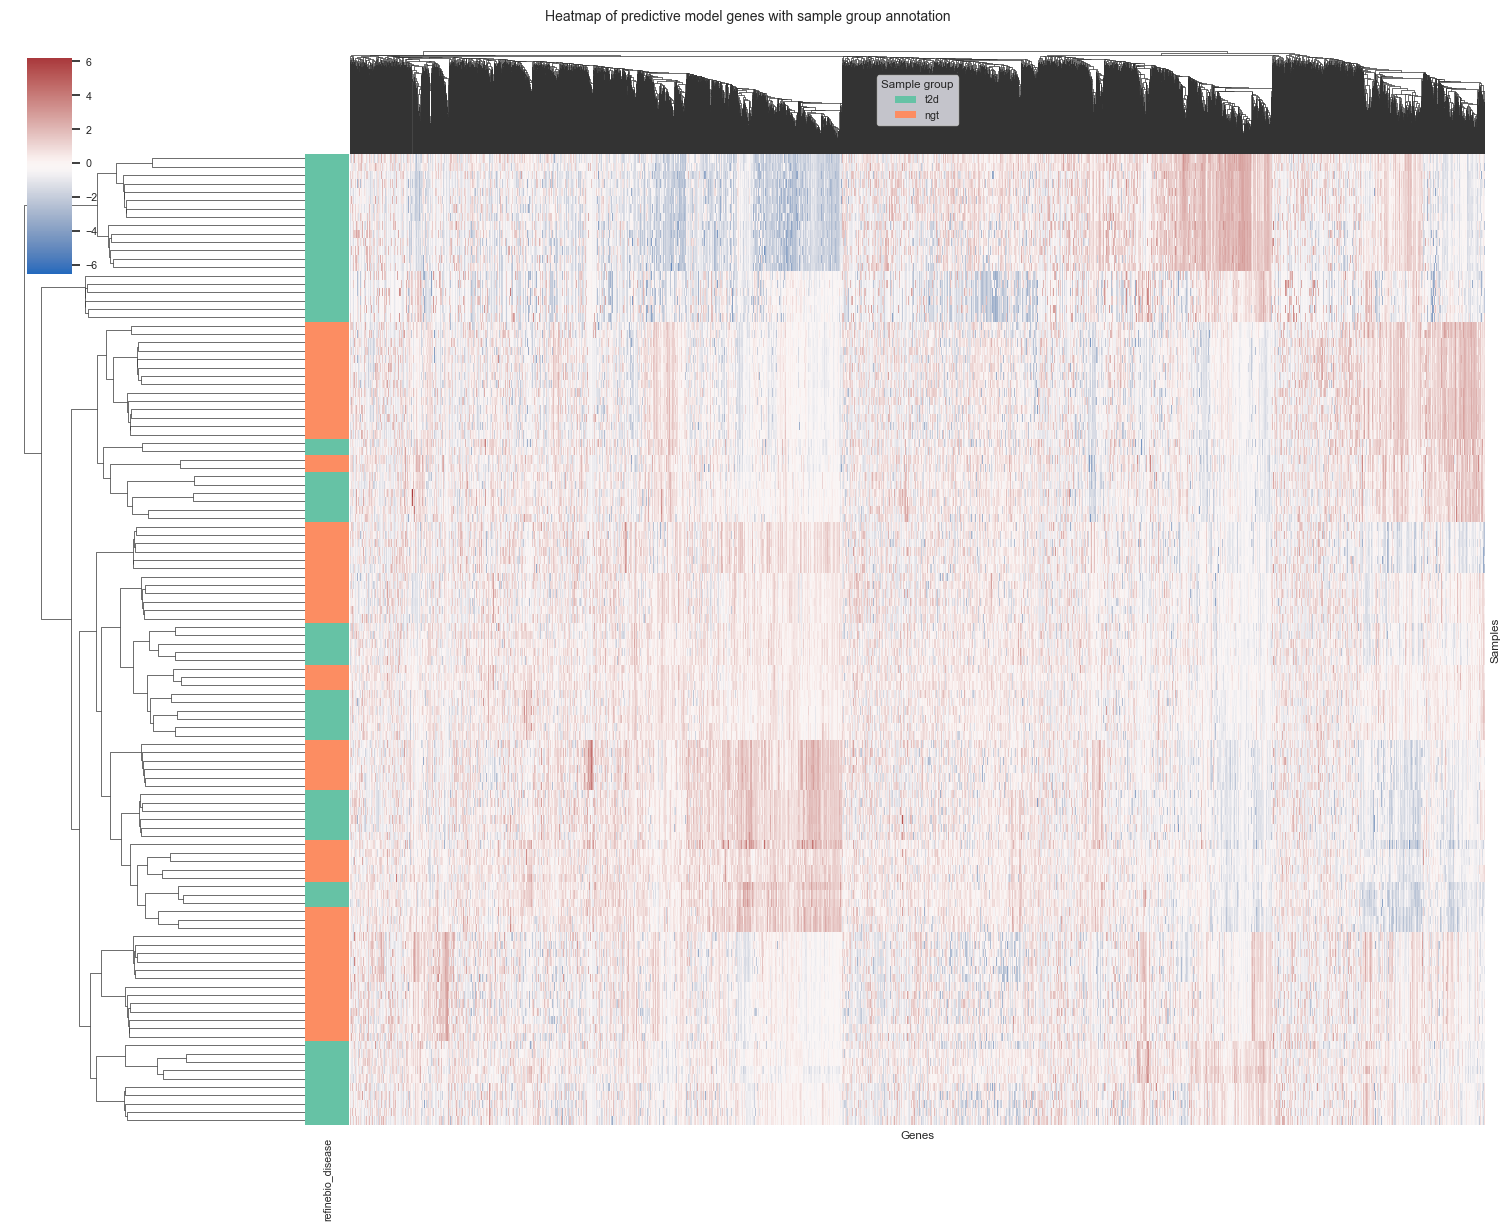

In [ ]:
selected_genes = set()
for n in [10, 100, 1000, 10000]:
    selected_genes.update(gene_subsets[n].columns.tolist())

selected_genes = list(selected_genes)
print(f"Total unique genes selected: {len(selected_genes)}")

# Subset expression data
expr_subset = expr_log.loc[selected_genes].T  # samples x genes

# Ensure alignment with metadata
expr_subset = expr_subset.loc[meta.index.intersection(expr_subset.index)]
meta_subset = meta.loc[expr_subset.index]

# Standardize expression values
scaler = StandardScaler()
expr_scaled = pd.DataFrame(
    scaler.fit_transform(expr_subset),
    index=expr_subset.index,
    columns=expr_subset.columns
)

# Create a sidebar annotation for sample groups
sample_groups = meta_subset[target_col]

# Map to colors
group_palette = sns.color_palette("Set2", n_colors=sample_groups.nunique())
group_lut = dict(zip(sample_groups.unique(), group_palette))
row_colors = sample_groups.map(group_lut)

# Plot clustered heatmap
#sns.set(font_scale=0.7)
g = sns.clustermap(
    expr_scaled,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    figsize=(15, 12),
    cmap='vlag',  # blue-white-red
    standard_scale=None,
    xticklabels=False,
    yticklabels=False,
    dendrogram_ratio=(0.2, 0.1),
    cbar_pos=(0.02, 0.8, 0.03, 0.18)  # x, y, width, height
)

# Add legend for sample groups
for label in sample_groups.unique():
    g.ax_col_dendrogram.bar(0, 0, color=group_lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(title='Sample group', loc="center", ncol=1)

# Labels
g.ax_heatmap.set_xlabel("Genes")
g.ax_heatmap.set_ylabel("Samples")
plt.suptitle("Heatmap of predictive model genes with sample group annotation", y=1.02)
plt.show()
